## Sharing data

In [1]:
%reload_ext autoreload
%autoreload 2

### 1. Decode
These files, due to size, are written to disk rather than inserted into the database. The database keeps the file path only.

These files are uploaded to Dropbox for sharing with Mattar Lab.

For recording keeping for Shijie, below are code to obtain file path from the database.

In [2]:
from spyglass.shijiegu.Analysis_SGU import (EpochPos,TrialChoice,Decode,
DecodeIngredients,DecodeResultsLinear)

[2026-03-12 12:23:29,515][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [3]:
key = {"nwb_file_name":"julio20230801_.nwb",
       "classifier_param_name":"default_decoding_gpu_4armMaze",
       "encoding_set":"2Dheadspeed_above_4"}

In [4]:
(DecodeResultsLinear() & key).fetch("posterior")

array(['/cumulus/shijie/recording_pilot/julio/decoding/julio20230801_.nwb_02_Seq2Session1_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_result.nc',
       '/cumulus/shijie/recording_pilot/julio/decoding/julio20230801_.nwb_04_Seq2Session2_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_result.nc',
       '/cumulus/shijie/recording_pilot/julio/decoding/julio20230801_.nwb_06_Seq2Session3_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_result.nc',
       '/cumulus/shijie/recording_pilot/julio/decoding/julio20230801_.nwb_08_Seq2Session4_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_result.nc',
       '/cumulus/shijie/recording_pilot/julio/decoding/julio20230801_.nwb_10_Seq2Session5_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_result.nc',
       '/cumulus/shijie/recording_pilot/julio/decoding/julio20230801_.nwb_12_Seq2Session6_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_result.nc'],
      dtype=object)

#### How to load decode:

In [39]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

def select_subset_helper(xr_ob,plottimes,target_len = 0,epsilon = 0):
    if xr_ob is None:
        return None
    xr_ob = xr_ob.sel(
        time=xr_ob.time[
            np.logical_and(xr_ob.time>=plottimes[0],xr_ob.time<=plottimes[1])])
    if target_len > 0 and len(xr_ob.time) > 0:
        xr_ob2 = xr_ob.isel(time= slice(0,target_len))
        if (np.abs(xr_ob2.time[0]-plottimes[0])<=epsilon) and (np.abs(xr_ob2.time[-1]-plottimes[1])<=epsilon):
            return xr_ob2
        else:
            print("some missing position data")
            return xr_ob
        
    return xr_ob

In [8]:
# suppose this is the path to the decoding file
decoding_path = '/cumulus/shijie/recording_pilot/lewis/decoding/lewis20240107_.nwb_06_Rev2Session3_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_result.nc'

posterior = xr.open_dataset(decoding_path)

In [9]:
posterior

<xarray.Dataset> Size: 7GB
Dimensions:            (time: 924740, state: 2, position: 301)
Coordinates:
  * time               (time) float64 7MB 1.705e+09 1.705e+09 ... 1.705e+09
  * position           (position) float64 2kB 0.9938 2.981 4.969 ... 740.1 742.0
  * state              (state) object 16B 'Continuous' 'Uniform'
Data variables:
    likelihood         (time, state, position) float32 2GB ...
    causal_posterior   (time, state, position) float32 2GB ...
    acausal_posterior  (time, state, position) float32 2GB ...
Attributes:
    data_log_likelihood:  -567559.5

In [101]:
# just pick a snippet
t0 = posterior.time[10000].item()
plottimes = (t0, t0 + 5)

In [102]:
results_subset = select_subset_helper(posterior,plottimes)

# get posterior over position
posterior_position_subset=results_subset.acausal_posterior.sum(
            dim='state')

# get posterior over replay state
posterior_state_subset=results_subset.acausal_posterior.sum('position')

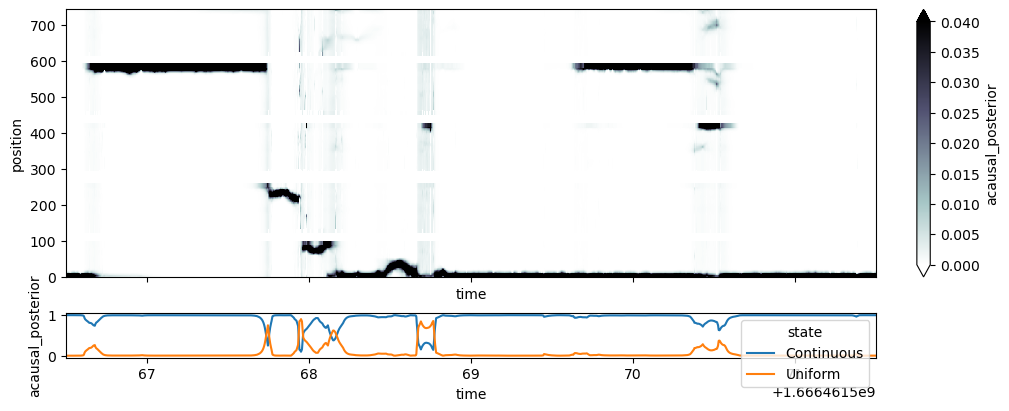

In [103]:
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True,
                             constrained_layout=True, gridspec_kw={"height_ratios": [3,0.5]},)

### plot posterior over position bins like this:
x_axis=np.arange(plottimes[0],plottimes[1],100)
posterior_position_subset.plot(
            x='time', y='position', ax=axes[0], rasterized=True, robust=True, cmap='bone_r', vmax = 0.04)

posterior_state_subset.plot(x='time',hue='state',ax=axes[1])

### 2. Ripple Times
Same as before, the files are parsed ripple intervals along with parsed meta data. 

For record keeping, here is the code Shijie used to copy files in the file system to one single folder to be uploaded to Dropbox to share with Mattar Lab.

In [5]:
from spyglass.shijiegu.Analysis_SGU import RippleTimesWithDecode
from spyglass.shijiegu.decodeHelpers import runSessionNames
import pandas as pd
import shutil

def copy_file(source_file, destination_path):
    try:
        shutil.copy(source_file, destination_path)
        print(f"File '{source_file}' copied successfully to '{destination_path}'.")
    except FileNotFoundError:
        print(f"Error: Source file '{source_file}' not found.")
    except Exception as e:
        print(f"An error occurred: {e}")

In [6]:
list_of_days_animals = {}

# animal = "lewis"
# list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110']

# animal = "eliot"
# list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']

animal = "molly"
list_of_days_animals[animal] = ['20220416','20220417','20220418','20220419','20220420']

animal = "julio"

list_of_days_animals[animal] = ['20230801','20230802','20230803','20230804',
                                '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
dropbox_path = "/cumulus/shijie/MattarLab/ripple_times"

In [16]:
key = {"nwb_file_name":'molly20220418_.nwb',
                   "interval_list_name": session_name}
RippleTimesWithDecode() & key

nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,classifier_param_name a name for this set of parameters,encoding_set a name for this set of encoding,decode_threshold_method a name for this thresholding method,ripple_times ripple times within that interval
molly20220418_.nwb,02_Seq2Session1,default_decoding_gpu_4armMaze,2Dheadspeed_above_4,MUA_0SD,=BLOB=
molly20220418_.nwb,02_Seq2Session1,default_decoding_gpu_4armMaze,2Dheadspeed_above_4,MUA_M05SD,=BLOB=


In [15]:
key

{'nwb_file_name': 'molly20220418_.nwb',
 'interval_list_name': '02_Seq2Session1',
 'decode_threshold_method': 'MUA_05SD'}

In [19]:
for animal in ["julio"]:
    for d in list_of_days_animals[animal]:
        nwb_file_name = animal + d + '_.nwb'
        session_names, _ = runSessionNames(nwb_file_name)
        for session_name in session_names:
            key = {"nwb_file_name":nwb_file_name,
                   "interval_list_name": session_name,
                   "decode_threshold_method":"MUA_0SD"}

            source_file = (RippleTimesWithDecode() & key).fetch1("ripple_times")
            
            copy_file(source_file, dropbox_path)

File '/cumulus/shijie/recording_pilot/julio/decoding/julio20230801_.nwb_02_Seq2Session1_extended_ripple_times_with_decode.pkl' copied successfully to '/cumulus/shijie/MattarLab/ripple_times'.
File '/cumulus/shijie/recording_pilot/julio/decoding/julio20230801_.nwb_04_Seq2Session2_extended_ripple_times_with_decode.pkl' copied successfully to '/cumulus/shijie/MattarLab/ripple_times'.
File '/cumulus/shijie/recording_pilot/julio/decoding/julio20230801_.nwb_06_Seq2Session3_extended_ripple_times_with_decode.pkl' copied successfully to '/cumulus/shijie/MattarLab/ripple_times'.
File '/cumulus/shijie/recording_pilot/julio/decoding/julio20230801_.nwb_08_Seq2Session4_extended_ripple_times_with_decode.pkl' copied successfully to '/cumulus/shijie/MattarLab/ripple_times'.
File '/cumulus/shijie/recording_pilot/julio/decoding/julio20230801_.nwb_10_Seq2Session5_extended_ripple_times_with_decode.pkl' copied successfully to '/cumulus/shijie/MattarLab/ripple_times'.
File '/cumulus/shijie/recording_pilot/ju

#### How to read in ripple files.

In [104]:
example_file_path = '/cumulus/shijie/recording_pilot/eliot/decoding/eliot20221026_.nwb_12_Seq2Session6_extended_ripple_times_with_decode.pkl'

In [105]:
pd.read_pickle(example_file_path)

,start_time,end_time,animal_location,trial_number,cont_intvl,frag_intvl,cont_intvl_replay,duration,mean_zscore,median_zscore,max_zscore,min_zscore,speed_at_start,speed_at_end,max_speed,min_speed,median_speed,mean_speed
1,1.666828e+09,1.666828e+09,well3,1,"[[1666827745.1132278, 1666827745.237228]]",[],[[3]],0.126,1.115132,0.988496,3.372495,0.004264,2.641671,1.543351,2.817758,1.543351,2.651575,2.456055
2,1.666828e+09,1.666828e+09,well3,1,"[[1666827749.709227, 1666827749.749227]]","[[1666827749.7512271, 1666827749.835227]]",[[]],0.128,1.307439,0.933281,3.968376,-0.370188,1.228227,0.637061,1.228227,0.637061,0.961912,0.952435
3,1.666828e+09,1.666828e+09,home,2,"[[1666827761.471225, 1666827761.495225], [1666...","[[1666827761.497225, 1666827761.541225], [1666...","[[4], []]",0.208,3.286753,1.425812,15.144457,-0.139818,0.087148,0.087147,0.087148,0.087147,0.087148,0.087148
4,1.666828e+09,1.666828e+09,home,2,"[[1666827763.555225, 1666827763.6892247], [166...","[[1666827763.6912246, 1666827763.7112248]]","[[2], []]",0.228,3.985009,2.134417,15.434016,-0.608413,0.087147,0.087148,0.087148,0.087147,0.087148,0.087148
5,1.666828e+09,1.666828e+09,home,2,"[[1666827764.4832246, 1666827764.6212244]]","[[1666827764.6232245, 1666827764.6592245]]",[[0]],0.177,3.622743,3.111217,9.030773,-0.594313,0.069378,0.465966,0.465966,0.059846,0.134086,0.183943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,1.666829e+09,1.666829e+09,home,79,"[[1666829233.6989677, 1666829233.726967]]",[],[[]],0.030,2.401296,2.401957,5.122905,0.039616,1.251554,1.274591,1.274591,1.251554,1.263163,1.263157
163,1.666829e+09,1.666829e+09,well4,80,"[[1666829262.0289624, 1666829262.0709624], [16...","[[1666829262.0729623, 1666829262.1389625]]","[[], []]",0.142,2.142099,1.899257,5.286023,-0.665691,0.665015,0.286815,0.665015,0.121598,0.269713,0.327716
164,1.666829e+09,1.666829e+09,well4,80,"[[1666829262.2689624, 1666829262.3029623], [16...","[[1666829262.3049624, 1666829262.3469625]]","[[2], []]",0.175,3.997990,1.566748,18.122904,-0.451863,1.055739,2.444845,2.468382,1.055739,1.972100,1.898153
165,1.666829e+09,1.666829e+09,well4,80,"[[1666829262.5449624, 1666829262.5709624], [16...","[[1666829262.5729623, 1666829262.6009624]]","[[4], [4]]",0.121,2.122208,1.402144,8.359696,-0.797617,1.041857,1.791472,1.791472,0.461460,0.825474,0.956913


### 3. Animal location and Unsorted Spiking Multi-unit Activities

For record keeping, here is the code Shijie used to query from the database and copied data to the folder to share with Mattar lab.

In [55]:
dropbox_path_marks = "/cumulus/shijie/MattarLab/marks"
dropbox_path_pos1d = "/cumulus/shijie/MattarLab/pos1d"

In [ ]:
# position
for animal in ["molly","julio"]:
    for d in list_of_days_animals[animal]:
        nwb_file_name = animal + d + '_.nwb'
        session_names, _ = runSessionNames(nwb_file_name)
        for session_name in session_names:
            key = {"nwb_file_name":nwb_file_name,
                   "interval_list_name": session_name}

            source_file_pos1d = (DecodeIngredients() & key).fetch1("position_1d")
            source_file_pos2d = (DecodeIngredients() & key).fetch1("position_2d")
        
            copy_file(source_file_pos2d, dropbox_path_pos1d)
            copy_file(source_file_pos1d, dropbox_path_pos1d)

File '/cumulus/shijie/recording_pilot/molly/decoding/molly20220416_.nwb_02_Seq2Session1_2dposition.csv' copied successfully to '/cumulus/shijie/MattarLab/pos1d'.
File '/cumulus/shijie/recording_pilot/molly/decoding/molly20220416_.nwb_02_Seq2Session1_1dposition.csv' copied successfully to '/cumulus/shijie/MattarLab/pos1d'.
File '/cumulus/shijie/recording_pilot/molly/decoding/molly20220416_.nwb_04_Seq2Session2_2dposition.csv' copied successfully to '/cumulus/shijie/MattarLab/pos1d'.
File '/cumulus/shijie/recording_pilot/molly/decoding/molly20220416_.nwb_04_Seq2Session2_1dposition.csv' copied successfully to '/cumulus/shijie/MattarLab/pos1d'.
File '/cumulus/shijie/recording_pilot/molly/decoding/molly20220416_.nwb_06_Seq2Session3_2dposition.csv' copied successfully to '/cumulus/shijie/MattarLab/pos1d'.
File '/cumulus/shijie/recording_pilot/molly/decoding/molly20220416_.nwb_06_Seq2Session3_1dposition.csv' copied successfully to '/cumulus/shijie/MattarLab/pos1d'.
File '/cumulus/shijie/record

In [ ]:
for animal in ["molly","julio"]:
    for d in list_of_days_animals[animal]:
        nwb_file_name = animal + d + '_.nwb'
        session_names, _ = runSessionNames(nwb_file_name)
        for session_name in session_names:
            key = {"nwb_file_name":nwb_file_name,
                   "interval_list_name": session_name}

            source_file_mark = (DecodeIngredients() & key).fetch1("marks")
        
            copy_file(source_file_mark, dropbox_path_marks)

In [23]:
print("done")

done


#### How to load 1d, 2d position data

- Animals run in the 2D maze. Its position data can be loaded as follows.

In [100]:
example_pos2d_path = '/cumulus/shijie/recording_pilot/lewis/decoding/lewis20240106_.nwb_06_Rev2Session3_2dposition.csv'
pos2d = pd.read_csv(example_pos2d_path)
pos2d

,time,head_position_x,head_position_y,head_orientation,head_velocity_x,head_velocity_y,head_speed
0,1.704573e+09,123.839286,93.964286,-2.592315,-9.569296,0.576683,9.586657
1,1.704573e+09,123.827381,93.980159,-2.594389,-9.479466,0.649112,9.501664
2,1.704573e+09,123.815476,93.996032,-2.596463,-9.390374,0.718082,9.417790
3,1.704573e+09,123.803571,94.011905,-2.598539,-9.302005,0.783589,9.334951
4,1.704573e+09,123.791667,94.027778,-2.600614,-9.214341,0.845627,9.253063
...,...,...,...,...,...,...,...
729048,1.704575e+09,182.315476,50.940476,-1.894745,-2.075888,-3.034557,3.676663
729049,1.704575e+09,182.305556,50.944444,-1.894600,-2.001946,-3.011426,3.616141
729050,1.704575e+09,182.295635,50.948413,-1.894456,-1.927443,-2.989465,3.556956
729051,1.704575e+09,182.285714,50.952381,-1.894311,-1.852386,-2.968677,3.499197


- However, to aid analyses, the 2D environment is reduced a 1D environment mostly projected along the maze tracks.
Home arm -> track_segment_id = 0

Arm 1 -> track_segment_id = 6

Arm 2 -> track_segment_id = 7

Arm 3 -> track_segment_id = 8

Arm 4 -> track_segment_id = 9

Center Platform -> track_segment_id = 5

Start and end 1D coordinates for each track_segment:

{0: array([0, 57.63896252]),

 6: array([165.66041604, 252.64353221]),
 
 7: array([331.10211383, 418.29227956]),
 
 8: array([496.49241045, 583.18763812]),
 
 9: array([657.72023142, 743.03215907])}

#### How to load unsorted multi-unit activity

In [115]:
# how to load 
example_marks_path = '/cumulus/shijie/recording_pilot/lewis/decoding/lewis20240106_.nwb_06_Rev2Session3_marks.nc'
marks = xr.load_dataset(example_marks_path)
marks

<xarray.Dataset> Size: 507MB
Dimensions:                        (time: 729053, marks: 4, electrodes: 43)
Coordinates:
  * time                           (time) float64 6MB 1.705e+09 ... 1.705e+09
  * electrodes                     (electrodes) int32 172B 0 1 7 8 ... 58 61 62
  * marks                          (marks) object 32B 'amplitude_0000' ... 'a...
Data variables:
    __xarray_dataarray_variable__  (time, marks, electrodes) float32 502MB na...

### 4. Sorted units from select sessions
Below are code Shijie used to query the database to get the sorted spiking data.

In [32]:
list_of_days_animals = {}
encoding_set_animals = {}
classifier_param_name_animals = {}
seq_animals = {}
success_animal = {}

animal = 'eliot'
list_of_days_animals[animal] = ['20221018','20221019','20221021','20221022','20221023','20221024']
encoding_set_animals[animal] = '2Dheadspeed_above_4_andlowmua'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'seq2'

animal = "lewis"
list_of_days_animals[animal] = ["20240109",	"20240110","20240113"]#["20240107", "20240108","20240109",	"20240110","20240113"]
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'
seq_animals[animal] = 'rev2'

animal = 'molly'
list_of_days_animals[animal] = ['20220418']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'


animal = "julio"
list_of_days_animals[animal] = ["20230802","20230805","20230806"]
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'


bad_sessions = [('eliot', '20221019', '10_Seq2Session5'),
                ('lewis', '20240108', '06_Rev2Session3'),
                ('lewis', '20240108', '08_Rev2Session4'),
               ('lewis', '20240113', '02_Rev2Session1'),
               ('molly', '20220418', '06_Seq2Session3'),
               ('molly', '20220418', '08_Seq2Session4'),
               ('molly', '20220418', '10_Seq2Session5'),
                ('julio', '20230801', '12_Seq2Session6'),
               ('julio', '20230802', '02_Seq2Session1'),
               ('julio', '20230802', '04_Seq2Session2'),
               ('julio', '20230802', '06_Seq2Session3'),
               ('julio', '20230802', '08_Seq2Session4'),] # these sessions have incomplete number of sorted tetrodes

In [33]:
from spyglass.shijiegu.theta_singleUnit import return_list_of_spike_train
from spyglass.shijiegu.placefield_simple import place_field
import os

dropbox_path_spikes = "/cumulus/shijie/MattarLab/sorted_spikes"

In [34]:
success = {}
for animal in ["julio"]:
    for d in list_of_days_animals[animal]:
        nwb_file_name = animal + d + '_.nwb'
        session_names, _ = runSessionNames(nwb_file_name)
        for session_name in session_names:
            if (animal, d, session_name) in bad_sessions:
                continue

            # get spikes
            spike_trains, nwb_units, cell_types = return_list_of_spike_train(nwb_file_name,
                                                                 session_name,
                                                                 pyramidal_only = False)

            # calculate place fields for all units
            
            key = {"nwb_file_name": nwb_file_name,
                   "interval_list_name": session_name}
            
            source_file_pos1d = (DecodeIngredients() & key).fetch1("position_1d")
            source_file_pos2d = (DecodeIngredients() & key).fetch1("position_2d")
            pos1d = pd.read_csv(source_file_pos1d)
            pos2d = pd.read_csv(source_file_pos2d)
            
            placefields = {}
            peak_firing_rates = {}
            run_spike_counts = {}
            still_spike_counts = {}
            for (e,u) in cell_types.keys():
                spike_times = nwb_units[e].loc[u].spike_times
                (placefields[(e,u)], peak_firing_rates[(e,u)],
                 xbins, ybins, run_spike_counts[(e,u)], still_spike_counts[(e,u)]) = place_field(pos1d, pos2d, spike_times)

            # make pandas table, with index as (sort group id, unit id), columns are spike times
            spike_info = {}
            for e in nwb_units:
                units = nwb_units[e].index
                for u in units:
                    spike_info[(e, u)] = {"spike_times": nwb_units[e].loc[u].spike_times,
                                          "unit_type": cell_types[(e,u)],
                                          "place_field": placefields[(e,u)],
                                          "peak_firing_rate": peak_firing_rates[(e,u)],
                                          "run_spike_count": run_spike_counts[(e,u)],
                                          "still_spike_count":still_spike_counts[(e,u)],
                                          }

            df = pd.DataFrame.from_dict(spike_info, orient = 'index')
            df.index.names = ['sort_group_id','unit_id']
            
            # Save the DataFrame to a pickle file
            df.to_pickle(os.path.join(dropbox_path_spikes,f"{nwb_file_name}_{session_name}_sorted_units.pkl"))

            success[(nwb_file_name, session_name)] = 1
            print("DataFrame saved as pkl")

[2026-03-12 18:24:20,197][WARNING]: Skipped checksum for file with hash: 79731841-6cc2-b0ce-b3d3-d0163199a23a, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_VMBJORCTSJ.nwb
[2026-03-12 18:24:20,208][WARNING]: Skipped checksum for file with hash: 79731841-6cc2-b0ce-b3d3-d0163199a23a, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_VMBJORCTSJ.nwb
[2026-03-12 18:24:20,218][WARNING]: Skipped checksum for file with hash: 79731841-6cc2-b0ce-b3d3-d0163199a23a, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_VMBJORCTSJ.nwb
[2026-03-12 18:24:20,225][WARNING]: Skipped checksum for file with hash: 79731841-6cc2-b0ce-b3d3-d0163199a23a, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_VMBJORCTSJ.nwb
[2026-03-12 18:24:30,209][WARNING]: Skipped checksum for file with hash: 240710f6-c026-e97c-6974-c34bdfd37056, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_7RWL6RDCAZ.nwb
[2026-03-12 18:24:30,217][WARNING]: Skipped checksum for file with hash: 24

spike num: 22873
spike num: 321
spike num: 5401
spike num: 496
spike num: 45428
spike num: 1757
spike num: 483
spike num: 1030
spike num: 299
spike num: 97
spike num: 522
spike num: 672
spike num: 511
spike num: 855
spike num: 441
spike num: 432
spike num: 37268
spike num: 881
spike num: 1434
spike num: 778
spike num: 520
spike num: 441
spike num: 161
spike num: 258
spike num: 586
spike num: 233
spike num: 72
spike num: 101007
spike num: 1794
spike num: 1232
spike num: 1024
spike num: 1254
spike num: 66983
spike num: 31980
spike num: 2598
spike num: 384
spike num: 142
spike num: 2023
spike num: 126483
spike num: 352
spike num: 1421
spike num: 1634
spike num: 238
spike num: 4552
spike num: 1022
spike num: 779
spike num: 530
spike num: 445
spike num: 650
spike num: 323
spike num: 4747
spike num: 921
spike num: 695
spike num: 918
spike num: 131
spike num: 911
spike num: 1984
spike num: 770
spike num: 7672
spike num: 2341
spike num: 594
spike num: 1477
spike num: 598
spike num: 463
spike n

[2026-03-12 18:29:27,937][WARNING]: Skipped checksum for file with hash: 1ed18498-5cb3-b704-b889-1c3fedae1d45, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_JLPC639YW2.nwb
[2026-03-12 18:29:27,946][WARNING]: Skipped checksum for file with hash: 1ed18498-5cb3-b704-b889-1c3fedae1d45, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_JLPC639YW2.nwb
[2026-03-12 18:29:27,955][WARNING]: Skipped checksum for file with hash: 1ed18498-5cb3-b704-b889-1c3fedae1d45, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_JLPC639YW2.nwb
[2026-03-12 18:29:27,960][WARNING]: Skipped checksum for file with hash: 1ed18498-5cb3-b704-b889-1c3fedae1d45, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_JLPC639YW2.nwb


DataFrame saved as pkl


[2026-03-12 18:29:37,980][WARNING]: Skipped checksum for file with hash: f77885a2-c7a9-e98a-0440-7abc90b3995c, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_OXNOYV4UK1.nwb
[2026-03-12 18:29:37,989][WARNING]: Skipped checksum for file with hash: f77885a2-c7a9-e98a-0440-7abc90b3995c, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_OXNOYV4UK1.nwb
[2026-03-12 18:29:37,998][WARNING]: Skipped checksum for file with hash: f77885a2-c7a9-e98a-0440-7abc90b3995c, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_OXNOYV4UK1.nwb
[2026-03-12 18:29:38,004][WARNING]: Skipped checksum for file with hash: f77885a2-c7a9-e98a-0440-7abc90b3995c, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_OXNOYV4UK1.nwb
[2026-03-12 18:29:47,709][WARNING]: Skipped checksum for file with hash: 83b99ba4-f183-0bd5-9c49-d3b69e2897f0, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_QVKB6WVARB.nwb
[2026-03-12 18:29:47,720][WARNING]: Skipped checksum for file with hash: 83

...

spike num: 28426
spike num: 6657
spike num: 658
spike num: 245
spike num: 1914
spike num: 128839
spike num: 1927
spike num: 1904
spike num: 2700
spike num: 803
spike num: 81
spike num: 671
spike num: 1186
spike num: 2868
spike num: 415
spike num: 342
spike num: 1125
spike num: 29252
spike num: 54
spike num: 441
spike num: 474
spike num: 250
spike num: 1746
spike num: 3469
spike num: 837
spike num: 371
spike num: 270
spike num: 604
spike num: 1515
spike num: 362
spike num: 175
spike num: 96424
spike num: 2056
spike num: 76
spike num: 182
spike num: 2128
spike num: 270
spike num: 1941
spike num: 2359
spike num: 288
spike num: 107
spike num: 72446
spike num: 1671
spike num: 60833
spike num: 82257
spike num: 2476
spike num: 2584
spike num: 53293
spike num: 1103
spike num: 322
spike num: 1311
spike num: 667
spike num: 303
spike num: 82
spike num: 1551
spike num: 1839
spike num: 1073
spike num: 1355
spike num: 1499
spike num: 342
spike num: 4296
spike num: 5091
spike num: 4264
spike num: 313

[2026-03-12 19:09:13,010][WARNING]: Skipped checksum for file with hash: a0f92e24-6e46-bb00-649d-c4e4178812b1, and path: /stelmo/nwb/analysis/Julio20230806/Julio20230806_XLLKH62ZDA.nwb
[2026-03-12 19:09:13,020][WARNING]: Skipped checksum for file with hash: a0f92e24-6e46-bb00-649d-c4e4178812b1, and path: /stelmo/nwb/analysis/Julio20230806/Julio20230806_XLLKH62ZDA.nwb
[2026-03-12 19:09:13,029][WARNING]: Skipped checksum for file with hash: a0f92e24-6e46-bb00-649d-c4e4178812b1, and path: /stelmo/nwb/analysis/Julio20230806/Julio20230806_XLLKH62ZDA.nwb
[2026-03-12 19:09:13,035][WARNING]: Skipped checksum for file with hash: a0f92e24-6e46-bb00-649d-c4e4178812b1, and path: /stelmo/nwb/analysis/Julio20230806/Julio20230806_XLLKH62ZDA.nwb


DataFrame saved as pkl


[2026-03-12 19:09:22,453][WARNING]: Skipped checksum for file with hash: f901cbb7-e1c8-30da-817d-e0449b623c84, and path: /stelmo/nwb/analysis/Julio20230806/Julio20230806_1B4Z1ZLMJK.nwb
[2026-03-12 19:09:22,462][WARNING]: Skipped checksum for file with hash: f901cbb7-e1c8-30da-817d-e0449b623c84, and path: /stelmo/nwb/analysis/Julio20230806/Julio20230806_1B4Z1ZLMJK.nwb
[2026-03-12 19:09:22,470][WARNING]: Skipped checksum for file with hash: f901cbb7-e1c8-30da-817d-e0449b623c84, and path: /stelmo/nwb/analysis/Julio20230806/Julio20230806_1B4Z1ZLMJK.nwb
[2026-03-12 19:09:22,476][WARNING]: Skipped checksum for file with hash: f901cbb7-e1c8-30da-817d-e0449b623c84, and path: /stelmo/nwb/analysis/Julio20230806/Julio20230806_1B4Z1ZLMJK.nwb
[2026-03-12 19:09:31,877][WARNING]: Skipped checksum for file with hash: 8385f8ce-04df-bcb0-1911-ef9d746da6a3, and path: /stelmo/nwb/analysis/Julio20230806/Julio20230806_EV8VKHEV8P.nwb
[2026-03-12 19:09:31,888][WARNING]: Skipped checksum for file with hash: 83

spike num: 37952
spike num: 5144
spike num: 10701
spike num: 197
spike num: 512
spike num: 898
spike num: 957
spike num: 333
spike num: 2812
spike num: 1651
spike num: 1595
spike num: 478
spike num: 1418
spike num: 370
spike num: 1145
spike num: 450
spike num: 1010
spike num: 438
spike num: 1305
spike num: 2393
spike num: 475
spike num: 700
spike num: 383
spike num: 1419
spike num: 307
spike num: 91525
spike num: 2325
spike num: 1075
spike num: 144
spike num: 561
spike num: 1885
spike num: 1504
spike num: 181
spike num: 4313
spike num: 66951
spike num: 126
spike num: 1566
spike num: 312
spike num: 214
spike num: 57113
spike num: 117799
spike num: 1563
spike num: 838
spike num: 309
spike num: 613
spike num: 2255
spike num: 47956
spike num: 1745
spike num: 855
spike num: 177
spike num: 189
spike num: 201
spike num: 278
spike num: 730
spike num: 2079
spike num: 1453
spike num: 189
spike num: 3556
spike num: 3790
spike num: 4867
spike num: 1139
spike num: 5806
spike num: 544
spike num: 761

In [35]:
success

{('julio20230805_.nwb', '02_Seq2Session1'): 1,
 ('julio20230805_.nwb', '04_Seq2Session2'): 1,
 ('julio20230805_.nwb', '06_Seq2Session3a'): 1,
 ('julio20230805_.nwb', '07_Seq2Session3b'): 1,
 ('julio20230805_.nwb', '09_Seq2Session4'): 1,
 ('julio20230806_.nwb', '02_Seq2Session1'): 1,
 ('julio20230806_.nwb', '04_Seq2Session2'): 1,
 ('julio20230806_.nwb', '06_Seq2Session3'): 1,
 ('julio20230806_.nwb', '08_Seq2Session4'): 1,
 ('julio20230806_.nwb', '10_Seq2Session5'): 1}

In [30]:
%debug

> /home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/datajoint/fetch.py(332)__call__()
    330             )
    331             if len(result) != 1:
--> 332                 raise DataJointError(
    333                     "fetch1 should only return one tuple. %d tuples found" % len(result)
    334                 )



ipdb>  key


<class 'datajoint.fetch.key'>


ipdb>  u


> /home/shijiegu/Documents/spyglass/src/spyglass/shijiegu/theta_singleUnit.py(52)return_list_of_spike_train()
     50        "curation_id":1}
     51 
---> 52     cell_type_pd = pd.DataFrame((SingleUnit() & key).fetch1("cell_type_pd"))
     53     sort_groups = np.unique([ind[0] for ind in cell_type_pd.index])
     54 



ipdb>  key


{'nwb_file_name': 'julio20230801_.nwb', 'sorter': 'mountainsort4', 'epoch': 12, 'curation_id': 1}


ipdb>  exit


#### How to load spiking data

In [116]:
example_spiking_path = '/cumulus/shijie/MattarLab/sorted_spikes/eliot20221018_.nwb_02_Seq2Session1_sorted_units.pkl'
df = pd.read_pickle(example_spiking_path)

In [117]:
df

spike_times  \
sort_group_id unit_id                                                      
0             3        [1666121994.8492334, 1666121995.008767, 166612...   
2             2        [1666122043.0108392, 1666122072.6725967, 16661...   
              3        [1666121995.689601, 1666121995.7517343, 166612...   
              4        [1666121996.3506348, 1666122002.0962057, 16661...   
              5        [1666122005.631276, 1666122014.0333824, 166612...   
...                                                                  ...   
30            7        [1666122006.4768763, 1666122007.3133771, 16661...   
31            2        [1666121992.522098, 1666121992.546565, 1666121...   
              3        [1666121996.0639677, 1666121996.4035347, 16661...   
              5        [1666121992.7040985, 1666121992.8236985, 16661...   
              7        [1666122002.6159732, 1666122002.64884, 1666122...   

                          unit_type  \
sort_group_id unit_id                 
0             3           pyramidal   
2             2           pyramidal   
              3           pyramidal   
              4           pyramidal   
              5           pyramidal   
...                             ...   
30            7           pyramidal   
31            2         interneuron   
              3           pyramidal   
              5        unclassified   
              7           pyramidal   

                                                             place_field  \
sort_group_id unit_id                                                      
0             3        [[nan, nan, nan, nan, nan, nan, nan, nan, nan,...   
2             2        [[nan, nan, nan, nan, nan, nan, nan, nan, nan,...   
              3        [[nan, nan, nan, nan, nan, nan, nan, nan, nan,...   
              4        [[nan, nan, nan, nan, nan, nan, nan, nan, nan,...   
              5        [[nan, nan, nan, nan, nan, nan, nan, nan, nan,...   
...                                                                  ...   
30            7        [[nan, nan, nan, nan, nan, nan, nan, nan, nan,...   
31            2        [[nan, nan, nan, nan, nan, nan, nan, nan, nan,...   
              3        [[nan, nan, nan, nan, nan, nan, nan, nan, nan,...   
              5        [[nan, nan, nan, nan, nan, nan, nan, nan, nan,...   
              7        [[nan, nan, nan, nan, nan, nan, nan, nan, nan,...   

                       peak_firing_rate  run_spike_count  still_spike_count  
sort_group_id unit_id                                                        
0             3               11.740238             1375               2165  
2             2                0.211344               10                153  
              3                6.322910              559                608  
              4               11.210232              635                766  
              5               15.647227              972               1173  
...                                 ...              ...                ...  
30            7               17.757712              260                302  
31            2               36.677255            17826              25538  
              3               24.317389              762               1276  
              5               44.134724            11472              21013  
              7                0.867234               19                162  

[112 rows x 6 columns]

In [125]:
### suppose we are interested unit (sort_group_id = 2, unit_id = 5)
(e,u) = (2,5) #electrode, unit

In [126]:
#### spike times
spike_times = df.loc[e,u].spike_times

In [127]:
#### unit type: either pyramidal or interneuron or unclassified
unit_type = df.loc[e,u].unit_type
print(f"Unit {(e,u)} is {unit_type}.")

Unit (2, 5) is pyramidal.


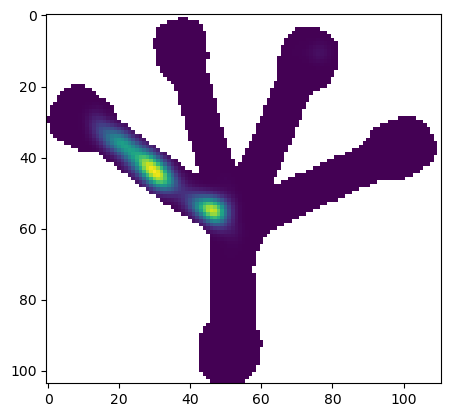

In [128]:
### place field
smoothed_placefield = df.loc[e,u].place_field
plt.imshow(smoothed_placefield)

### 5. LFP trace

In [40]:
from spyglass.shijiegu.Analysis_SGU import TrialChoice,EpochPos,RippleTimes,LFPBandArtifact,ChannelNumber
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.common import IntervalList

In [41]:
from spyglass.shijiegu.ripple_detection import get_electrodes_table, loadRippleLFP_OneChannelPerElectrode
from spyglass.shijiegu.load import load_LFP

In [48]:
animal = 'molly'
list_of_days_animals[animal] = ['20220415']


animal = "julio"
list_of_days_animals[animal] = ["20230801","20230803","20230804","20230807",
                                "20230808","20230809","20230810","20230811"]

In [49]:
dropbox_folder_lfp = '/cumulus/shijie/MattarLab/lfp/'

success = {}
for animal in ["molly"]:
    for d in list_of_days_animals[animal]: #organized by day
        nwb_copy_file_name = animal + d + '_.nwb'
        session_names, _ = runSessionNames(nwb_copy_file_name)
        session_name = session_names[0] # just pick a random date

        electrodes = get_electrodes_table(nwb_copy_file_name, session_name)

        # pick one channel per electrode
        electrodes = electrodes.reset_index()
        ntrode_ids = np.unique(electrodes.ntrode_id)
            
        indices = []
        for ntrode_id in ntrode_ids:
            electrodes_subset = electrodes[electrodes.ntrode_id == ntrode_id]
            electrodes_subset_good = electrodes_subset[electrodes_subset.bad_channel == False]
            indices.append(electrodes_subset_good.index[0])

        # load LFP
        lfp, lfp_t = load_LFP(nwb_copy_file_name,session_name)

        # Create xarray Dataset
        lfp_subset = lfp[:,indices]
        lfp_df = pd.DataFrame(data = lfp_subset, index=lfp_t, columns = ["channel"+str(i) for i in range(len(indices))])
        lfp_df.index.name='time'
        lfp_xr = xr.Dataset.from_dataframe(lfp_df)

        # save xarray
        lfp_xr.to_netcdf(os.path.join(dropbox_folder_lfp,
                              f"{nwb_copy_file_name}_lfp.nc"))

        success[(nwb_copy_file_name)] = True

[2026-03-13 10:25:17,719][WARNING]: Skipped checksum for file with hash: a40d7d14-6ff3-73a7-8d7d-46d62c7c3974, and path: /stelmo/nwb/analysis/molly20220415/molly20220415_M0EOMJGB1L.nwb
[2026-03-13 10:25:27,606][WARNING]: Skipped checksum for file with hash: 4d956d5c-2f96-3988-0981-cdaf2aa594cc, and path: /stelmo/nwb/analysis/molly20220415/molly20220415_R4XRXOPMGH.nwb
[2026-03-13 10:25:27,614][WARNING]: Skipped checksum for file with hash: 4d956d5c-2f96-3988-0981-cdaf2aa594cc, and path: /stelmo/nwb/analysis/molly20220415/molly20220415_R4XRXOPMGH.nwb
[2026-03-13 10:25:27,622][WARNING]: Skipped checksum for file with hash: 4d956d5c-2f96-3988-0981-cdaf2aa594cc, and path: /stelmo/nwb/analysis/molly20220415/molly20220415_R4XRXOPMGH.nwb
[2026-03-13 10:25:27,626][WARNING]: Skipped checksum for file with hash: 4d956d5c-2f96-3988-0981-cdaf2aa594cc, and path: /stelmo/nwb/analysis/molly20220415/molly20220415_R4XRXOPMGH.nwb


#### How to load broad band LFP

In [241]:
example_lfp_path = "/cumulus/shijie/MattarLab/lfp/eliot20221018_.nwb_lfp.nc"
lfp = xr.load_dataset(example_lfp_path)

In [242]:
lfp

<xarray.Dataset> Size: 980MB
Dimensions:    (time: 22277677)
Coordinates:
  * time       (time) float64 178MB 1.666e+09 1.666e+09 ... 1.666e+09 1.666e+09
Data variables: (12/18)
    channel0   (time) int16 45MB 48 121 143 204 263 277 ... 74 72 77 45 37 43
    channel1   (time) int16 45MB -10 -16 -4 53 99 111 ... 244 236 201 206 221
    channel2   (time) int16 45MB -4 -4 32 109 161 197 ... 108 106 121 100 84 84
    channel3   (time) int16 45MB -15 0 49 113 159 155 ... 9 39 39 -11 -15 -20
    channel4   (time) int16 45MB 101 212 208 248 289 294 ... -9 -19 -45 -55 -70
    channel5   (time) int16 45MB -53 -87 -3 68 92 62 62 ... 116 110 123 81 66 90
    ...         ...
    channel12  (time) int16 45MB 39 87 61 87 113 106 125 ... 77 52 21 -21 7 67
    channel13  (time) int16 45MB 131 258 215 227 248 ... -71 -95 -145 -126 -73
    channel14  (time) int16 45MB -47 -116 -108 -67 -32 ... 284 228 156 160 206
    channel15  (time) int16 45MB 65 116 80 115 146 147 ... 110 83 57 -3 21 84
    channel16  (time) int16 45MB 91 197 165 182 199 180 ... 103 60 27 -22 18 112
    channel17  (time) int16 45MB 84 186 153 166 182 174 ... 141 121 76 121 177

### 6. Ripple Band LFP

In [50]:
def load_ripple_LFP(nwb_file_name, epochID):
    nwb_copy_file_name=get_nwb_copy_filename(nwb_file_name)

    # find epoch/session name and position interval name
    key = (EpochPos & {'nwb_file_name':nwb_copy_file_name,'epoch':epochID}).fetch1()
    epoch_name = key['epoch_name']
    position_interval = key['position_interval']
    is_run_session = False
    if epoch_name.split('_')[1][4:8] == 'Sess':
        is_run_session = True

    position_valid_times = (IntervalList & {'nwb_file_name': nwb_copy_file_name,
                                            'interval_list_name': position_interval}).fetch1('valid_times')

    # Ripple Band LFP
    filtered_lfps, filtered_lfps_t, CA1TetrodeInd, CCTetrodeInd = loadRippleLFP_OneChannelPerElectrode(
        nwb_copy_file_name,epoch_name,position_valid_times, fieldname = "filtered data")

    return filtered_lfps, filtered_lfps_t, CA1TetrodeInd, CCTetrodeInd

In [247]:
nwb_file_name = "eliot20221021.nwb"

In [52]:
dropbox_folder_lfp = '/cumulus/shijie/MattarLab/ripple_lfp/'

In [56]:
animal = 'molly'
list_of_days_animals[animal] = ['20220415','20220416','20220417',
                                '20220418','20220419','20220420']


animal = "julio"
list_of_days_animals[animal] = ["20230801","20230802","20230803","20230804",
                                "20230805","20230806","20230807",
                                "20230808","20230809","20230810","20230811"]

In [ ]:
success = {}
for animal in ["molly","julio"]:
    for d in list_of_days_animals[animal]:
        nwb_file_name = animal + d + '.nwb'
        nwb_file_copy_name = animal + d + '_.nwb'
        session_names, _ = runSessionNames(nwb_file_copy_name)
        for session_name in session_names:
            if (animal, d, session_name) in bad_sessions:
                continue
                
            filtered_lfps, filtered_lfps_t, CA1TetrodeInd, CCTetrodeInd = load_ripple_LFP(
                nwb_file_name, str(session_name[:2]))

            # Create xarray Dataset
            lfp_df = pd.DataFrame(data = filtered_lfps, index=filtered_lfps_t, columns = ["channel"+str(i) for i in range(filtered_lfps.shape[1])])
            lfp_df.index.name='time'
            lfp_xr = xr.Dataset.from_dataframe(lfp_df)
            
            # save xarray
            lfp_xr.to_netcdf(os.path.join(dropbox_folder_lfp,
                                          f"{nwb_file_copy_name}_ripple_lfp.nc"))

[2026-03-13 14:02:18,652][WARNING]: Skipped checksum for file with hash: a40d7d14-6ff3-73a7-8d7d-46d62c7c3974, and path: /stelmo/nwb/analysis/molly20220415/molly20220415_M0EOMJGB1L.nwb


Using LFP from these eletrodes: 
[ 0  2  3  6  7  9 12 15 17 18 24 25 27 28 34 37 39 40 41 43 46 50 53 55
 61]




[2026-03-13 14:02:34,756][WARNING]: Skipped checksum for file with hash: 0d0c585c-9596-14fc-6f72-3366ff160a4a, and path: /stelmo/nwb/analysis/molly20220415/molly20220415_LFPXD0B0G8.nwb


Using LFP from these eletrodes: 
[ 0  2  3  6  7  9 12 15 17 18 24 25 27 28 34 37 39 40 41 43 46 50 53 55
 61]




[2026-03-13 14:02:51,905][WARNING]: Skipped checksum for file with hash: 0cb9af6a-6204-58b6-6669-0886564c755e, and path: /stelmo/nwb/analysis/molly20220415/molly20220415_793NIBKU5A.nwb


...

[2026-03-13 14:07:40,961][WARNING]: Skipped checksum for file with hash: 550b17e1-1391-85af-b594-266609b90117, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_VBYDSFCQK2.nwb


Using LFP from these eletrodes: 
[ 0  2  3  6  7  9 10 12 15 17 18 24 25 27 34 37 39 40 41 46 50 52 53 60
 61]




[2026-03-13 14:07:58,654][WARNING]: Skipped checksum for file with hash: 5cd8370b-ffc2-9929-addd-97338ba19690, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_34M8GRQF5I.nwb


Using LFP from these eletrodes: 
[ 0  2  3  6  7  9 10 12 15 17 18 24 25 27 34 37 39 40 41 46 50 52 53 60
 61]




[2026-03-13 14:08:16,278][WARNING]: Skipped checksum for file with hash: 425313ea-5237-c2d2-0910-52cd888ca013, and path: /stelmo/nwb/analysis/molly20220420/molly20220420_ROA5FMVJLQ.nwb


#### How to load ripple data